## Latency Metrics

In [1]:
from experiment_analysis import load_experiment_latencies

# Load experiment 3 from ./experiments/3
df = load_experiment_latencies(exp_id=20, experiments_root="/home/data/saeid/experiments")
df.head()
df.describe(percentiles=[0.5, 0.9, 0.99])[[
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]]


,end_to_end_s
count,9999.000000
mean,128.388264
std,91.578982
min,0.144270
50%,118.715811
90%,282.511054
99%,349.356802
max,523.038367


In [2]:
df

,idx,req_id,send_failed,end_to_end_s,model_latency_s,finish_reason,prompt_tokens,completion_tokens,total_tokens,endpoint_id,...,serving_node,applied_time_offset_s,client_to_router_s,router_queue_s,router_to_sidecar_s,sidecar_queue_s,vllm_compute_s,sidecar_post_s,sidecar_to_router_s,router_result_handler_s
0,6,dba0ff08dce5439c8a412ac7faa3c12c,False,0.232243,0.187632,stop,450,3,453,vllm-qwen3-8b-66bb9646dc-vmb44,...,None,NaN,-504.739115,0.000400,0.005470,0.000707,0.195253,0.000013,0.004975,9.536743e-07
1,5,837406a9edcc4a2e967a99c35910bcf2,False,0.589585,0.541877,stop,268,23,291,vllm-qwen3-8b-66bb9646dc-pvg5b,...,None,NaN,-504.738769,0.000412,0.008592,0.000873,0.548968,0.000012,0.005235,1.430511e-06
2,10,6d0504b988764a2ea9e168941b8c176e,False,0.208102,0.173388,stop,457,4,461,vllm-qwen3-8b-66bb9646dc-jbpq9,...,None,NaN,-504.739213,0.000356,0.002434,0.000312,0.174961,0.000013,0.005077,1.668930e-06
3,8,a0b821942ff04c128ae46660c6c05ea3,False,1.235497,1.197659,stop,511,61,572,vllm-qwen3-8b-66bb9646dc-9r55p,...,None,NaN,-504.739349,0.000353,0.002468,0.000329,1.199315,0.000013,0.008219,1.907349e-06
4,0,ceee6294eeff41cc9d630040c93dd68a,False,2.842328,2.578487,stop,354,132,486,vllm-qwen3-8b-66bb9646dc-9r55p,...,None,NaN,-504.713938,0.190036,0.011895,0.002598,2.585019,0.000020,0.002723,1.668930e-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9994,9823,c3f1d859a49d4063bf94b23f1570865b,False,365.088731,189.912849,length,403,8192,8595,vllm-qwen3-8b-66bb9646dc-zmdrp,...,None,NaN,-504.726611,0.000355,0.002422,175.094666,189.914868,0.000010,0.005330,9.536743e-07
9995,9444,465ccd1b6d444486a55da6f6522cd2ee,False,467.484548,181.215317,length,458,8192,8650,vllm-qwen3-8b-66bb9646dc-mvrqf,...,None,NaN,-504.726946,0.000390,0.002198,286.189123,181.217751,0.000008,0.004955,1.430511e-06
9996,9878,4ffceca781584899a1dbd7ccdb2d71b4,False,471.953274,173.891542,length,422,8192,8614,vllm-qwen3-8b-66bb9646dc-vmb44,...,None,NaN,-504.726568,0.000301,0.001783,297.979563,173.894961,0.000013,0.006519,4.768372e-07
9997,9874,53a4610576394761877be631f7bea9cb,False,477.433468,173.545451,length,366,8192,8558,vllm-qwen3-8b-66bb9646dc-jbpq9,...,None,NaN,-504.726798,0.000279,0.002023,303.788718,173.547264,0.000013,0.020745,1.192093e-06


In [3]:
from experiment_analysis import experiments_from_series

In [4]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison

series_ids = [35]

[42]


[42]

Average latencies per experiment:

[time_offsets] APPLY_TIME_OFFSETS=True

Experiment 42:
  client_to_router_s          :      nan s
  router_queue_s              :      nan s
  router_to_sidecar_s         :      nan s
  sidecar_queue_s             :      nan s
  vllm_compute_s              :      nan s
  sidecar_post_s              :      nan s
  sidecar_to_router_s         :      nan s
  router_post_result_s        :      nan s
  SUM (components)            :    0.000 s

  Router post-result breakdown:
    router_result_handler_s   :      nan s
    router_wakeup_s           :      nan s
    router_response_build_s   :      nan s
    router_after_return_stamp_s:      nan s
    SUM (post breakdown)      : 0.000000 s

  end_to_end_s                :   55.709 s



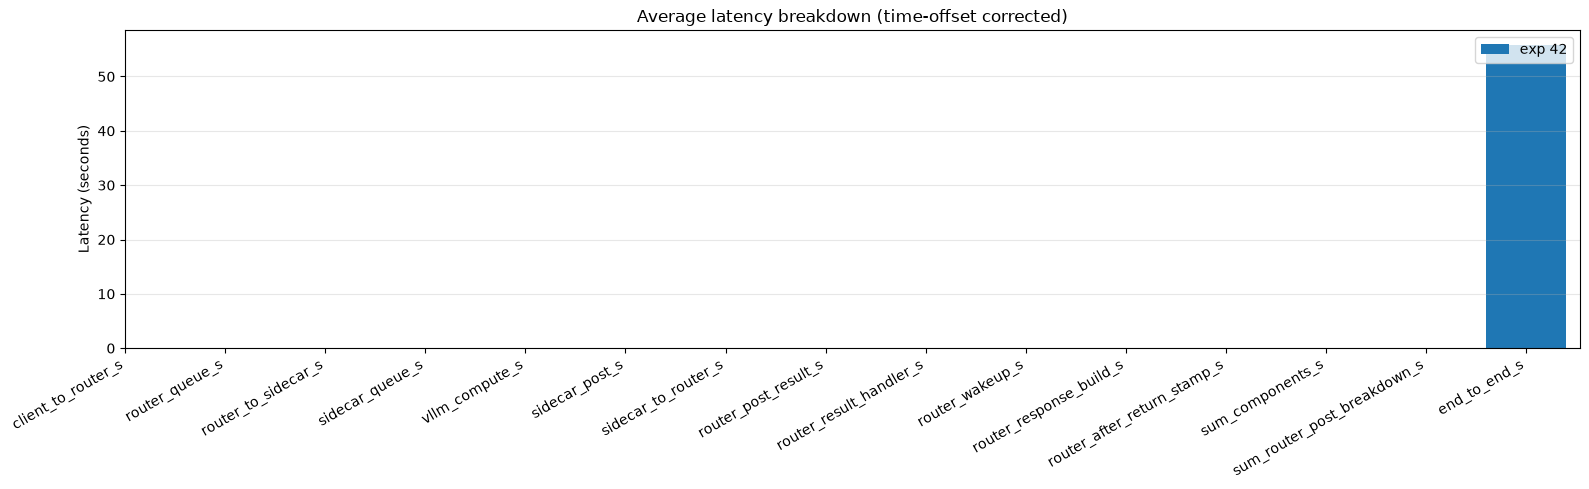

In [5]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt
import numpy as np

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]
print(experiments)
# ---------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# Non-overlapping latency components (base)
component_cols = [
    "client_to_router_s",
    "router_queue_s",
    "router_to_sidecar_s",
    "sidecar_queue_s",
    "vllm_compute_s",
    "sidecar_post_s",
    "sidecar_to_router_s",
    "router_post_result_s",
]

# router post-result breakdown (should sum ~ router_post_result_s when present)
router_post_breakdown_cols = [
    "router_result_handler_s",     # time spent inside /result handler (very small normally)
    "router_wakeup_s",             # waiter unblocked -> wait_for_result returns
    "router_response_build_s",     # build/merge trace/rename fields
    "router_after_return_stamp_s", # any last stamp after response object prepared (if you keep it)
]

extra_component_cols = [
    # keep empty unless you explicitly expose more metrics columns
]

e2e_col = "end_to_end_s"

plot_cols = (
    component_cols
    + router_post_breakdown_cols
    + extra_component_cols
    + ["sum_components_s", "sum_router_post_breakdown_s", e2e_col]
)

avg_by_exp = {}

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        apply_time_offset_correction=APPLY_TIME_OFFSETS,
        experiments_root="/home/data/saeid/experiments"
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    # Base component means
    comp_means = df.reindex(columns=component_cols).mean(numeric_only=True)
    sum_components = float(comp_means.sum(skipna=True))

    # Router post breakdown means
    post_means = df.reindex(columns=router_post_breakdown_cols).mean(numeric_only=True)
    sum_post_breakdown = float(post_means.sum(skipna=True))

    # Optional extras
    extra_means = df.reindex(columns=extra_component_cols).mean(numeric_only=True)

    e2e_mean = float(df[e2e_col].mean()) if e2e_col in df.columns else float("nan")

    row = {}

    for k in component_cols:
        row[k] = float(comp_means.get(k, np.nan))

    for k in router_post_breakdown_cols:
        row[k] = float(post_means.get(k, np.nan))

    for k in extra_component_cols:
        row[k] = float(extra_means.get(k, np.nan))

    row["sum_components_s"] = sum_components
    row["sum_router_post_breakdown_s"] = sum_post_breakdown
    row[e2e_col] = e2e_mean

    avg_by_exp[exp_id] = row

# ---- print numbers ----
print("\nAverage latencies per experiment:\n")
print(f"[time_offsets] APPLY_TIME_OFFSETS={APPLY_TIME_OFFSETS}\n")

for exp_id in experiments:
    r = avg_by_exp[exp_id]
    print(f"Experiment {exp_id}:")

    for k in component_cols:
        print(f"  {k:28s}: {r[k]:8.3f} s")

    print(f"  {'SUM (components)':28s}: {r['sum_components_s']:8.3f} s")
    print()

    print("  Router post-result breakdown:")
    for k in router_post_breakdown_cols:
        print(f"    {k:26s}: {r[k]:8.6f} s")
    print(f"    {'SUM (post breakdown)':26s}: {r['sum_router_post_breakdown_s']:8.6f} s")

    base_post = r.get("router_post_result_s", np.nan)
    if not (np.isnan(base_post) or np.isnan(r["sum_router_post_breakdown_s"])):
        diff = base_post - r["sum_router_post_breakdown_s"]
        print(f"    {'router_post_result_s':26s}: {base_post:8.6f} s")
        print(f"    {'DIFF (base - sum)':26s}: {diff:8.6f} s")
    print()

    print(f"  {e2e_col:28s}: {r[e2e_col]:8.3f} s")
    print()

# ---- grouped bar plot ----
labels = plot_cols
x = np.arange(len(labels))
width = 0.8 / max(1, len(experiments))

plt.figure(figsize=(16, 5))

for i, exp_id in enumerate(experiments):
    vals = [avg_by_exp[exp_id].get(k, np.nan) for k in labels]
    plt.bar(x + i * width, vals, width, label=f"exp {exp_id}")

plt.xticks(
    x + width * (len(experiments) - 1) / 2,
    labels,
    rotation=30,
    ha="right"
)
plt.ylabel("Latency (seconds)")
plt.title(
    "Average latency breakdown (time-offset corrected)"
    if APPLY_TIME_OFFSETS
    else "Average latency breakdown (raw clocks)"
)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [6]:
from experiment_analysis import load_experiment_latencies
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]
print(experiments)

# ----------------------------------------------

# Latency columns of interest
cols = [
    "end_to_end_s",
    "ttft_s"
    # "server_roundtrip_s",
    # "router_queue_s",
    # "vllm_compute_s",
]

percentiles = [0.5, 0.9, 0.99]

summaries = []

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    df = df.iloc[20:]
    summary = (
        df.describe(percentiles=percentiles)[cols]
          .add_prefix(f"exp{exp_id}_")
    )

    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)

comparison


[42]


,exp42_end_to_end_s,exp42_ttft_s
count,2094.000000,2094.000000
mean,55.610280,3.473374
std,109.408179,4.269656
min,0.930380,0.517650
50%,23.377840,1.698095
90%,108.912704,8.551594
99%,652.268807,21.410699
max,1179.283220,35.175910


In [7]:
# from experiment_analysis import load_experiment_latencies
# import pandas as pd
# # ---- choose experiments (exclude first 20 entries) ----
# # choose which series you want
# # series_ids = [35]
# # experiments = experiments_from_series(series_ids)
# experiments = [42]
# print(experiments)
# # ----------------------------------------------
# # Latency columns of interest
# cols = [
#     "end_to_end_s",
#     # "server_roundtrip_s",
#     # "router_queue_s",
#     # "vllm_compute_s",
# ]
# percentiles = [0.5, 0.9, 0.99]
# summaries = []
# for exp_id in experiments:
#     df = load_experiment_latencies(exp_id=exp_id)
#     df = df.iloc[20:]
#     summary = (
#         df.describe(percentiles=percentiles)[cols]
#           .add_prefix(f"exp{exp_id}_")
#     )
#     summaries.append(summary)
# # Combine all experiments side-by-side
# comparison = pd.concat(summaries, axis=1)
# comparison


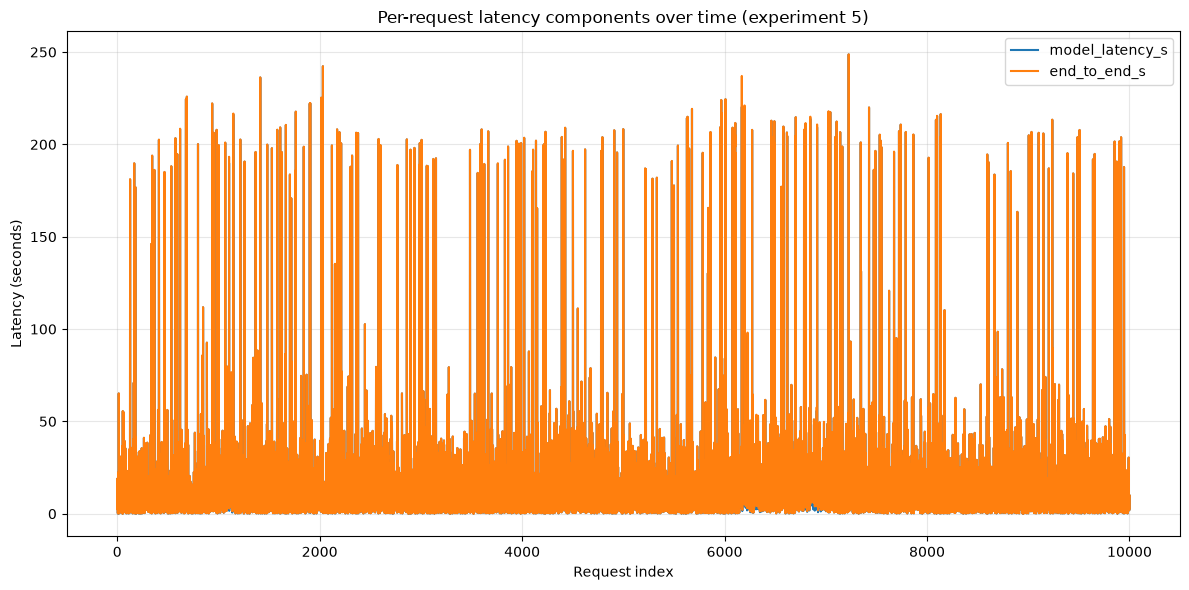

In [8]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiment ----
exp_id = 5
# ---------------------------

# Load and order by request index (or any monotonic field you prefer)
df = load_experiment_latencies(
    exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments").sort_values("idx").reset_index(drop=True)

# X-axis: request index (0, 1, 2, ...)
x = df["idx"]

# Latency metrics to plot over time
latency_cols = [
    "model_latency_s",
    "end_to_end_s",
    # "server_roundtrip_s",
    # "router_queue_s",
    # "router_to_sidecar_s",
    # "sidecar_queue_s",
    # "vllm_compute_s",
]

plt.figure(figsize=(12, 6))

for col in latency_cols:
    if col in df.columns:
        plt.plot(x, df[col], label=col)

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(f"Per-request latency components over time (experiment {exp_id})")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[42]


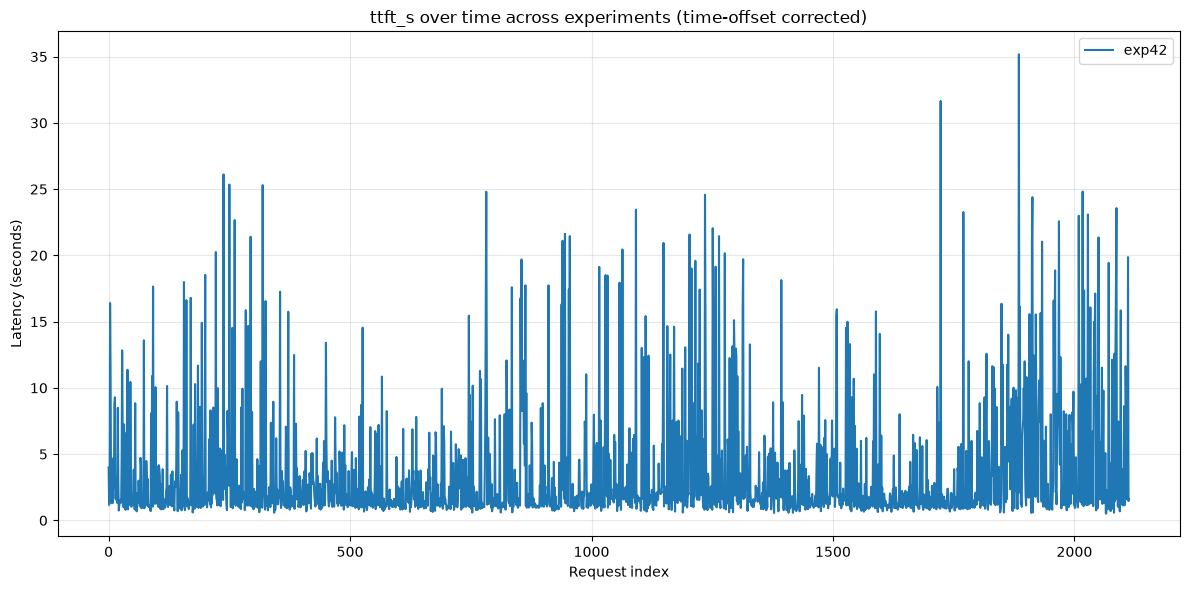

In [9]:
from experiment_analysis import load_experiment_latencies, experiments_from_series
import matplotlib.pyplot as plt

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------

# ============================================================
# TIME CORRECTION FLAG (NEW)
# ============================================================
APPLY_TIME_OFFSETS = True   # <- set False to revert to old behavior
# ============================================================

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "end_to_end_s"          # total client → router → server → client
metric = "ttft_s"
# metric = "server_roundtrip_s"  # router → vLLM → router
# metric = "router_queue_s"      # waiting time in router queue
# metric = "router_to_sidecar_s" # router → sidecar hop
# metric = "sidecar_queue_s"     # waiting time inside sidecar
# metric = "vllm_compute_s"      # actual model compute time
# metric = "router_post_result_s"
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            apply_time_offset_correction=APPLY_TIME_OFFSETS,
            experiments_root="/home/data/saeid/experiments"
        )
        .sort_values("idx")
        .reset_index(drop=True)
    )

    # (optional) sanity: how many requests actually got corrected?
    if APPLY_TIME_OFFSETS and "applied_time_offset_s" in df.columns:
        n_corr = int(df["applied_time_offset_s"].notna().sum())
        print(f"[exp {exp_id}] corrected_requests={n_corr}/{len(df)}")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Latency (seconds)")
plt.title(
    f"{metric} over time across experiments "
    + ("(time-offset corrected)" if APPLY_TIME_OFFSETS else "(raw clocks)")
)
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Throughput Metrics

In [10]:
# Split the sum and mean group based on metric characteristics.
# SLO violation for TTFT and TPOT, can be customised based on the target SLO. For Qwen3-8B model, assume the SLO for TTFT is 500ms, for TPOT is 50 ms

from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]
print(experiments)
# ----------------------------------------------

# Prometheus metric columns of interest
# (these are the fields inside each "samples" object in metrics.jsonl)

# aggregated by SUM across instances per tick
sum_cols = [
    "gen_tokens_per_sec",
    # "prefill_tokens_per_sec",
    # "requests_running",       # sum = cluster total queue depth; use mean if single-instance or want per-instance avg
    # "requests_waiting",       # same as above
    # "request_success_per_sec",
    # "request_failure_per_sec",
    # "preemptions_per_sec",
]

# aggregated by MEAN across instances per tick
# (these are pre-averaged histograms inside vLLM)
mean_cols = [
    # vLLM latency hist averages (if your vLLM exposes them)
    "ttft_seconds_avg",
    "tpot_seconds_avg",
    # "e2e_latency_seconds_avg",
    # "queue_time_seconds_avg",
    # "inference_time_seconds_avg",
    # "prefill_time_seconds_avg",
    # "decode_time_seconds_avg",

    # # token distribution hists (averages)
    # "request_prompt_tokens_avg",
    # "request_generation_tokens_avg",
    # "request_max_generation_tokens_avg",

    # # spec decode (optional)
    # "spec_tokens_accepted_per_sec",  # debatable: could be sum if you want cluster total
    # "spec_tokens_draft_per_sec",
    # "spec_tokens_emitted_per_sec", 
    # "gpu_kv_cache_usage_frac", # only available in GPU set up 
    # "cpu_kv_cache_usage_frac",
]

percentiles = [0.5, 0.9, 0.99]

# SLO thresholds
TTFT_SLO_S = 0.500  # 500ms in seconds
TPOT_SLO_S = 0.050  # 50ms in seconds

summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    # ---- CLUSTER VIEW (recommended): sum across instances per tick ----
    valid_sum_cols  = [c for c in sum_cols  if c in prom.columns]
    valid_mean_cols = [c for c in mean_cols if c in prom.columns]

    missing = set(sum_cols + mean_cols) - set(prom.columns)
    if missing:
        print(f"[WARN] exp{exp_id}: columns not found in prom, skipping: {missing}")

    agg_sum  = prom.groupby("ts")[valid_sum_cols].sum(min_count=1).reset_index()
    agg_mean = prom.groupby("ts")[valid_mean_cols].mean().reset_index()
    agg = agg_sum.merge(agg_mean, on="ts", how="outer")

    # Describe only the columns that actually exist in agg
    valid_all_cols = [c for c in (sum_cols + mean_cols) if c in agg.columns]
    summary = (
        agg[valid_all_cols]
        .describe(percentiles=percentiles)
        .add_prefix(f"exp{exp_id}_")
    )

    # ---- SLO compliance: % of ticks where metric is within SLO ----
    # NaN ticks (no completed requests) are excluded from both numerator and denominator
    if "ttft_seconds_avg" in agg.columns:
        ttft_col = agg["ttft_seconds_avg"].dropna()
        ttft_slo_pct = (ttft_col <= TTFT_SLO_S).mean() * 100
    else:
        ttft_slo_pct = float("nan")

    if "tpot_seconds_avg" in agg.columns:
        tpot_col = agg["tpot_seconds_avg"].dropna()
        tpot_slo_pct = (tpot_col <= TPOT_SLO_S).mean() * 100
    else:
        tpot_slo_pct = float("nan")

    # Build SLO row — NaN for all cols without a defined SLO
    slo_data = {f"exp{exp_id}_{c}": float("nan") for c in valid_all_cols}
    slo_data[f"exp{exp_id}_ttft_seconds_avg"] = ttft_slo_pct
    slo_data[f"exp{exp_id}_tpot_seconds_avg"] = tpot_slo_pct
    slo_row = pd.DataFrame(slo_data, index=["SLO_COMPLIANCE_%"])

    summary = pd.concat([summary, slo_row])
    summaries.append(summary)

# Combine all experiments side-by-side
comparison = pd.concat(summaries, axis=1)
comparison

[42]
[WARN] exp42: columns not found in prom, skipping: {'tpot_seconds_avg'}


,exp42_gen_tokens_per_sec,exp42_ttft_seconds_avg,exp42_tpot_seconds_avg
count,14.000000,14.000000,NaN
mean,241.694269,4.128863,NaN
std,62.339747,2.437802,NaN
min,158.241379,1.220829,NaN
50%,234.637931,3.873152,NaN
90%,287.448276,6.780881,NaN
99%,394.842069,9.240712,NaN
max,409.482759,9.570126,NaN
SLO_COMPLIANCE_%,NaN,0.000000,NaN


[42]


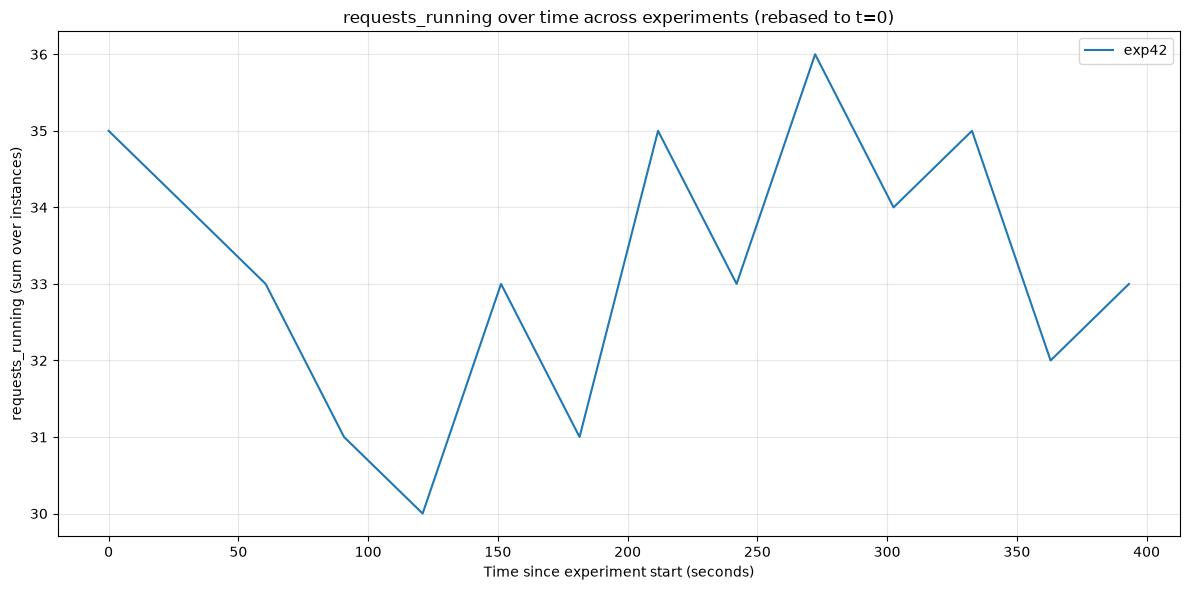

In [11]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "requests_running"
# metric = "gen_tokens_per_sec"
# metric = "prefill_tokens_per_sec"
# metric = "request_success_per_sec"
# metric = "request_failure_per_sec"
# metric = "preemptions_per_sec"
# metric = "gpu_kv_cache_usage_frac"
# metric = "cpu_kv_cache_usage_frac"
# metric = "requests_waiting"
# metric = "ttft_seconds_avg"
# metric = "tpot_seconds_avg"
# metric = "e2e_latency_seconds_avg"
# metric = "queue_time_seconds_avg"
# metric = "inference_time_seconds_avg"
# metric = "prefill_time_seconds_avg"
# metric = "decode_time_seconds_avg"
# metric = "request_prompt_tokens_avg"
# metric = "request_generation_tokens_avg"
# metric = "request_max_generation_tokens_avg"
# metric = "spec_tokens_accepted_per_sec"
# metric = "spec_tokens_draft_per_sec"
# metric = "spec_tokens_emitted_per_sec"

# -----------------------------------------------

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"   # cluster-level
# agg_mode = "mean"  # per-instance average
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
        experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue
    if metric not in prom.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Rebase time: each experiment starts at t=0
    t0 = prom["ts"].min()
    prom["t_rel_s"] = (prom["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick
    if agg_mode == "sum":
        series = prom.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances)"
    else:
        series = prom.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances)"

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


## Token Length Distribution

[42]


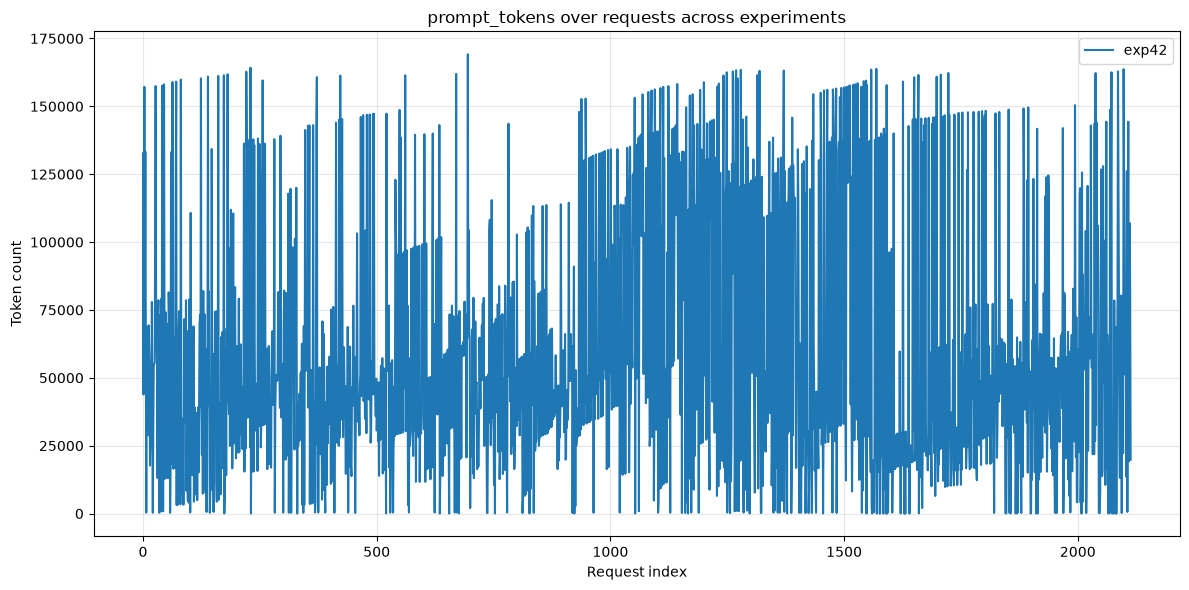

In [12]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
metric = "prompt_tokens"        # input length
# metric = "completion_tokens"  # output length
# metric = "total_tokens"       # input + output
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = (
        load_experiment_latencies(
            exp_id=exp_id,
            experiments_root="/home/data/saeid/experiments")
        .sort_values("idx")
        .reset_index(drop=True)
    )

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    x = df["idx"]
    y = df[metric]

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Request index")
plt.ylabel("Token count")
plt.title(f"{metric} over requests across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [13]:
from experiment_analysis import load_experiment_latencies

experiments = [42]

for exp_iexperiments in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")
    total = df["total_tokens"].sum()
    print(f"exp{exp_id}: {total} total tokens")

exp42: 0 total tokens


[42]


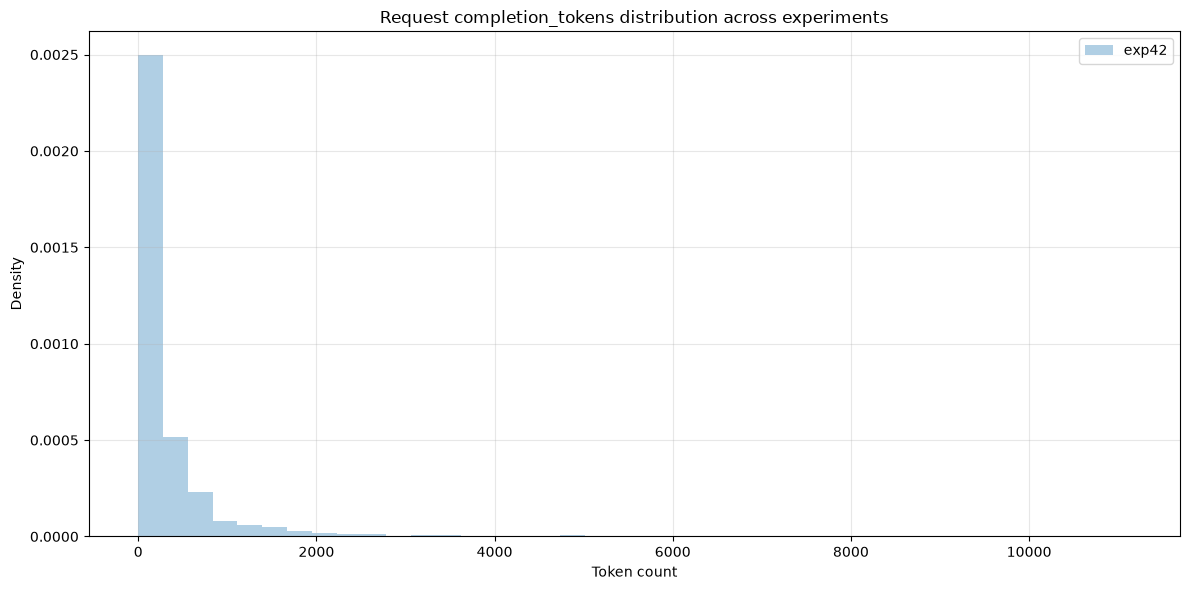

In [14]:
from experiment_analysis import load_experiment_latencies
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------

# ---- choose ONE metric (uncomment exactly one) ----
# metric = "prompt_tokens"        # input length distribution
metric = "completion_tokens"  # output length distribution
# metric = "total_tokens"       # input + output distribution
# -----------------------------------------------

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    df = load_experiment_latencies(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found")
        continue

    values = pd.to_numeric(df[metric], errors="coerce").dropna()
    if values.empty:
        print(f"Skipping exp{exp_id}: {metric} all NaN")
        continue

    plt.hist(
        values,
        bins=40,
        density=True,     # normalize so experiments are comparable
        alpha=0.35,
        label=f"exp{exp_id}",
    )

plt.xlabel("Token count")
plt.ylabel("Density")
plt.title(f"Request {metric} distribution across experiments")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


In [15]:
from pathlib import Path
import json
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------


def count_requests(exp_id, experiments_root="/home/data/saeid/experiments"):
    exp_dir = Path(experiments_root) / str(exp_id)
    logs_path = exp_dir / "logs.json"

    if not logs_path.exists():
        raise FileNotFoundError(f"logs.json not found for experiment {exp_id}")

    total = 0
    success = 0
    send_failed = 0

    with logs_path.open("r", encoding="utf-8") as f:
        for line in f:
            if not line.strip():
                continue
            rec = json.loads(line)
            total += 1

            if rec.get("send_failed", False):
                send_failed += 1
            else:
                success += 1

    return {
        "experiment": exp_id,
        "total_requests": total,
        "successful_requests": success,
        "connection_failed_requests": send_failed,
        "success_rate_pct": 100.0 * success / total if total > 0 else 0.0,
        "failure_rate_pct": 100.0 * send_failed / total if total > 0 else 0.0,
    }


rows = []
for exp_id in experiments:
    rows.append(count_requests(exp_id))

df_counts = pd.DataFrame(rows)
df_counts


[42]


,experiment,total_requests,successful_requests,connection_failed_requests,success_rate_pct,failure_rate_pct
0,42,2114,2114,0,100.0,0.0


In [16]:
from experiment_analysis import load_experiment_prom_samples
import pandas as pd

# -------- choose experiments to compare --------
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------------------------

percentiles = [0.5, 0.9, 0.99]

# ============================================================
# METRICS ONLY (the ones we added ourselves)
# Choose ONE:
#   "router_only"   -> only router metrics (from :8080 rows)
#   "sidecar_only"  -> only sidecar metrics (from :8200 rows)
#   "all_new"       -> both router + sidecar (two views, same table)
# ============================================================

METRICS_MODE = "all_new"  # <- change me

ROUTER_COLS = [
    "router_queue_length",
    "router_admission_rps",
    "router_outgoing_rps",
]

SIDECAR_COLS = [
    "sidecar_queue_length",
    "sidecar_received_rps",
    "sidecar_completed_rps",
]

MODE_TO_COLS = {
    "router_only": ROUTER_COLS,
    "sidecar_only": SIDECAR_COLS,
    "all_new": ROUTER_COLS + SIDECAR_COLS,
}

if METRICS_MODE not in MODE_TO_COLS:
    raise ValueError(f"Unknown METRICS_MODE={METRICS_MODE!r}. Choose one of: {sorted(MODE_TO_COLS)}")

SELECT_COLS = MODE_TO_COLS[METRICS_MODE]


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None


def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()


def _summarize_raw_cluster(df: pd.DataFrame, cols: list[str], exp_id: int) -> pd.DataFrame | None:
    """
    Cluster-view: aggregate across instances per tick, then describe across time.
    (No "coverage" output; just raw stats.)
    """
    if df.empty:
        return None

    cols = [c for c in cols if c in df.columns]
    if not cols:
        return None

    # per-tick aggregate across instances
    agg = df.groupby("ts")[cols].sum(min_count=1)

    # drop ticks where everything is missing (prevents NaN-only describe rows)
    agg = agg.dropna(how="all", subset=cols)
    if agg.empty:
        return None

    # if a metric is missing at some ticks, treat as 0 (keeps describe() clean)
    agg[cols] = agg[cols].fillna(0.0)

    # IMPORTANT: prefix ONLY with exp id (no redundant "sidecar_sidecar_*")
    return agg[cols].describe(percentiles=percentiles).add_prefix(f"exp{exp_id}_")


summaries = []

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"[WARN] exp{exp_id}: no prom metrics found (metrics.jsonl missing/empty)")
        continue

    router_df = _subset_by_port(prom, 8080)
    vllm_df = _subset_by_port(prom, 8200)

    if METRICS_MODE == "router_only":
        s = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s)

    elif METRICS_MODE == "sidecar_only":
        s = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s)

    else:  # all_new
        # Router metrics should come from router rows (:8080)
        s_router = _summarize_raw_cluster(router_df, ROUTER_COLS, exp_id)
        if s_router is None:
            print(f"[WARN] exp{exp_id}: no router (:8080) samples found")
        else:
            summaries.append(s_router)

        # Sidecar metrics should come from vLLM rows (:8200) (where we mapped them)
        s_sidecar = _summarize_raw_cluster(vllm_df, SIDECAR_COLS, exp_id)
        if s_sidecar is None:
            print(f"[WARN] exp{exp_id}: no vLLM (:8200) samples found for sidecar_*")
        else:
            summaries.append(s_sidecar)

comparison = pd.concat(summaries, axis=1) if summaries else pd.DataFrame()
comparison


[42]
[WARN] exp42: no vLLM (:8200) samples found for sidecar_*


,exp42_router_queue_length,exp42_router_admission_rps,exp42_router_outgoing_rps
count,14.0,14.000000,14.000000
mean,0.0,0.283251,0.142857
std,0.0,0.092900,0.073904
min,0.0,0.103448,0.034483
50%,0.0,0.258621,0.137931
90%,0.0,0.403448,0.231034
99%,0.0,0.443793,0.301379
max,0.0,0.448276,0.310345


[42]


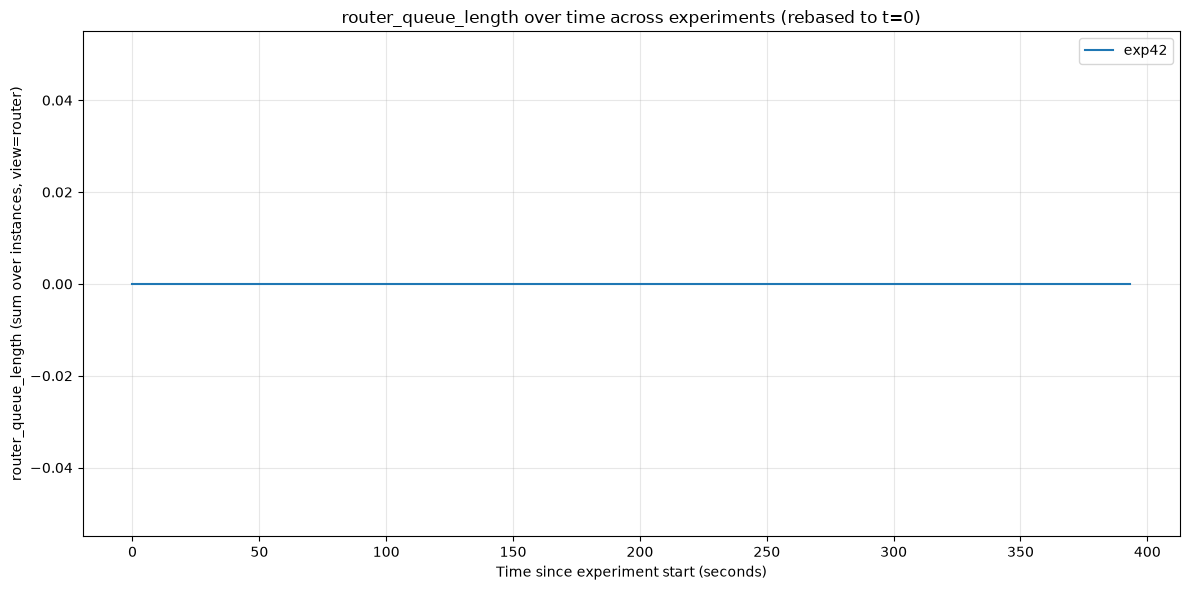

In [17]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd

# ---- choose experiments ----
# choose which series you want
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]

print(experiments)
# ----------------------------

# ============================================================
# METRICS ONLY (router + sidecar)
# Choose ONE metric (uncomment exactly one)
# ============================================================

# --- Router metrics ---
metric = "router_queue_length"
# metric = "router_admission_rps"
# metric = "router_outgoing_rps"

# --- Sidecar metrics ---
# metric = "sidecar_queue_length"
# metric = "sidecar_received_rps"
# metric = "sidecar_completed_rps"

# ============================================================
# Which "view" to plot?
#   - "router" : use :8080 rows (ground truth router pod)
#   - "vllm"   : use :8200 rows (broadcast router_* + mapped sidecar_*)
#
# Recommended:
#   - router_* -> view="router"
#   - sidecar_*-> view="vllm"
# ============================================================
view = "router"   # "router" or "vllm"

# ---- how to aggregate across instances per timestamp ----
agg_mode = "sum"    # "sum" (cluster-level) or "mean" (per-instance average)
# ---------------------------------------------------------

def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

# Auto-pick a sensible default view if user forgets
if view not in ("router", "vllm"):
    raise ValueError("view must be 'router' or 'vllm'")

if metric.startswith("sidecar_") and view == "router":
    print("[WARN] sidecar_* metrics live on vLLM (:8200) rows. Switching view -> 'vllm'.")
    view = "vllm"

if metric.startswith("router_") and view == "vllm":
    print("[NOTE] plotting router_* from vLLM (:8200) rows uses the broadcast values.")
    print("       If you want router ground-truth, set view='router'.")

plt.figure(figsize=(12, 6))

for exp_id in experiments:
    prom = load_experiment_prom_samples(exp_id=exp_id, experiments_root="/home/data/saeid/experiments")

    if prom.empty:
        print(f"Skipping exp{exp_id}: no prom samples")
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)

    # Pick the right rows
    if view == "router":
        df = _subset_by_port(prom, 8080)
    else:
        df = _subset_by_port(prom, 8200)

    if df.empty:
        print(f"Skipping exp{exp_id}: no rows for view={view!r}")
        continue

    if metric not in df.columns:
        print(f"Skipping exp{exp_id}: {metric} not found in view={view!r}")
        continue

    # Rebase time: each experiment starts at t=0 within this view
    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    # Aggregate across instances per tick (NaNs ignored; if all NaN at tick -> NaN)
    if agg_mode == "sum":
        series = df.groupby("t_rel_s")[metric].sum(min_count=1)
        y_label = f"{metric} (sum over instances, view={view})"
    elif agg_mode == "mean":
        series = df.groupby("t_rel_s")[metric].mean()
        y_label = f"{metric} (mean over instances, view={view})"
    else:
        raise ValueError("agg_mode must be 'sum' or 'mean'")

    x = series.index
    y = series.values

    plt.plot(x, y, label=f"exp{exp_id}")

plt.xlabel("Time since experiment start (seconds)")
plt.ylabel(y_label)
plt.title(f"{metric} over time across experiments (rebased to t=0)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)
plt.tight_layout()


[42]


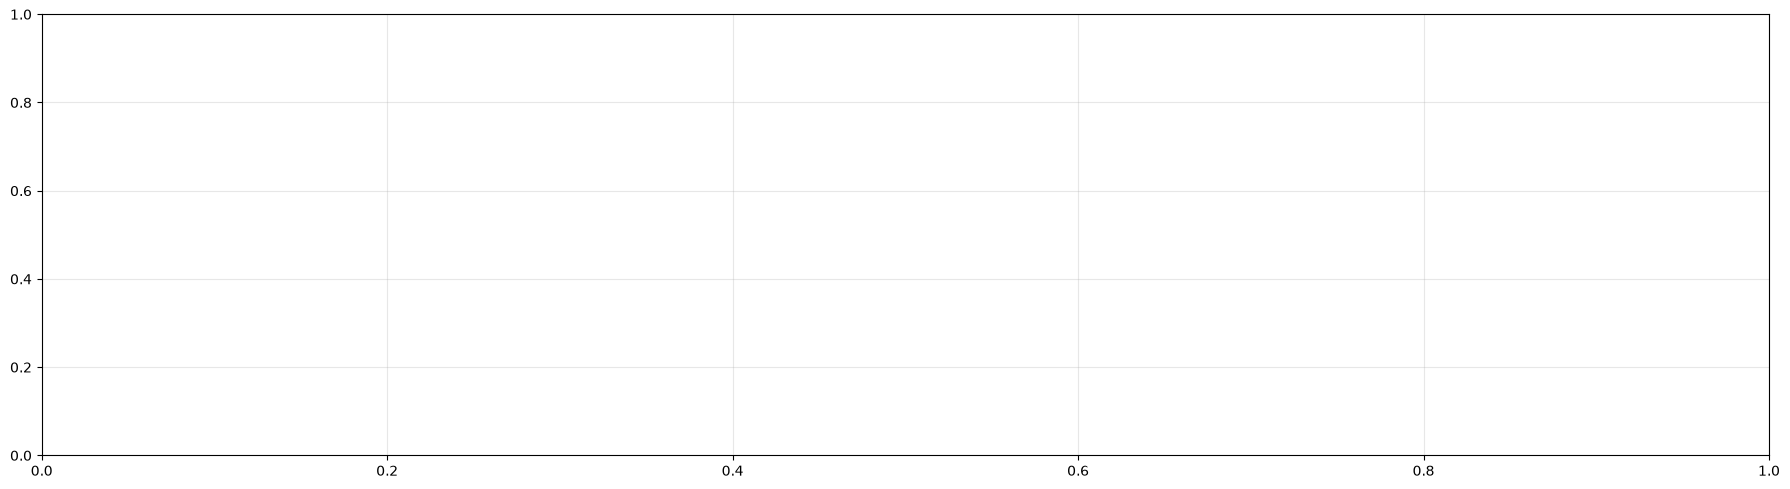

In [19]:
from experiment_analysis import load_experiment_prom_samples
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import re
import os

# ---- choose experiments ----
# series_ids = [35]
# experiments = experiments_from_series(series_ids)
experiments = [42]
print(experiments)

# ============================================================
# Choose ONE metric
# ============================================================
# metric = "sidecar_queue_length"
metric = "requests_running"
view = "vllm"  # sidecar_* live on vLLM (:8200)


def _port_of_instance(inst: str):
    try:
        _, port = str(inst).rsplit(":", 1)
        return int(port)
    except Exception:
        return None

def _subset_by_port(df: pd.DataFrame, port: int) -> pd.DataFrame:
    if df.empty:
        return df
    ports = df["instance"].map(_port_of_instance)
    return df.loc[ports == port].copy()

def _natural_key(s: str):
    parts = re.split(r"(\d+)", str(s))
    return [int(p) if p.isdigit() else p for p in parts]


# ------------------------------------------------------------
# FIRST PASS: load data + assign server1..serverN per experiment
# ------------------------------------------------------------
data_by_exp = {}
max_servers = 0

for exp_id in experiments:
    prom = load_experiment_prom_samples(
        exp_id=exp_id,
    experiments_root="/home/data/saeid/experiments")
    if prom.empty:
        continue

    prom = prom.sort_values("ts").reset_index(drop=True)
    df = _subset_by_port(prom, 8200)

    if df.empty or metric not in df.columns:
        continue

    t0 = df["ts"].min()
    df["t_rel_s"] = (df["ts"] - t0).dt.total_seconds()

    insts = sorted(df["instance"].dropna().unique().tolist(), key=_natural_key)
    slot_map = {inst: f"server{i+1}" for i, inst in enumerate(insts)}

    df = df.copy()
    df["server_slot"] = df["instance"].map(slot_map)

    data_by_exp[exp_id] = df
    max_servers = max(max_servers, len(insts))

# Canonical slot names
canonical_slots = [f"server{i}" for i in range(1, max_servers + 1)]

# ------------------------------------------------------------
# Consistent colors per slot
# ------------------------------------------------------------
cmap = plt.colormaps["tab20"].resampled(len(canonical_slots))
color_map = {slot: cmap(i) for i, slot in enumerate(canonical_slots)}

# ------------------------------------------------------------
# Plot panels
# ------------------------------------------------------------
fig, axes = plt.subplots(1, len(experiments), figsize=(18, 5), sharey=True)
if len(experiments) == 1:
    axes = [axes]

for ax, exp_id in zip(axes, experiments):
    df = data_by_exp.get(exp_id)
    if df is None or df.empty:
        ax.grid(True, alpha=0.3)
        continue

    for slot, g in df.groupby("server_slot"):
        if slot not in color_map:
            continue
        g = g.sort_values("t_rel_s")
        ax.plot(
            g["t_rel_s"],
            g[metric],
            color=color_map[slot],
            linewidth=1.5,
        )

    ax.set_xlabel("Time (s)")
    ax.grid(True, alpha=0.3)

plt.tight_layout()

# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------
os.makedirs("figures", exist_ok=True)
# plt.savefig(f"figures/{metric}_per_vllm_queue_comparison.png", dpi=300)

plt.show()
